# Análisis Final: Explicando el Churn al Negocio

## Caso Práctico - Empresa de Telecomunicaciones
## Prácticas Aplicadas 2026

---

## Objetivo de este notebook

Hasta ahora hemos construido y evaluado varios modelos de predicción de churn. En este notebook damos un paso más: **convertir los resultados técnicos en insights accionables para el negocio**.

El objetivo no es solo predecir quién se va, sino responder las preguntas que haría un director comercial:

- *¿Cómo es el cliente que abandona? ¿Qué perfil tiene?*
- *¿En qué zonas se concentra el problema?*
- *¿Puedo meter los datos de un cliente concreto y saber su riesgo?*
- *¿Funciona mejor el modelo si lo entreno por tipo de plan?*

Este notebook contiene cuatro secciones:
1. **Perfil del churner típico** — ¿quién es el cliente que se va?
2. **Mapa de riesgo por zona** — ¿dónde se concentra el churn?
3. **Simulador de cliente** — ¿cuál es el riesgo de un cliente concreto?
4. **Modelo por segmento** — ¿mejora el AUC si entrenamos un modelo por tipo de plan?


## 1. Librerías y carga de datos


In [2]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.load import load_all
from src.clean import clean_all

RANDOM_STATE = 42
PAL = {'No Churn': '#4C9BE8', 'Churn': '#E85C4C'}
print('Librerías cargadas')

Librerías cargadas


In [3]:
data  = load_all()
clean = clean_all(data, save=False)

clientes  = clean['clientes']
churn     = clean['churn']
factura   = clean['facturacion']
soporte   = clean['soporte']
calidad   = clean['calidad']

# Target: ever_churn por cliente
churn_agg = churn.groupby('cliente_id').agg(
    ever_churn         = ('churn', 'max'),
    n_meses_observados = ('churn', 'count'),
).reset_index()

# Facturación agregada por cliente
factura['mes'] = factura['fecha'].dt.to_period('M').dt.to_timestamp()
fac_agg = factura.groupby('cliente_id').agg(
    importe_medio      = ('importe_total',    'mean'),
    pct_meses_impago   = ('impago_flag',      'mean'),
    dias_retraso_medio = ('dias_retraso_pago','mean'),
    stress_medio       = ('stress_calidad_lag','mean'),
    n_meses_facturados = ('importe_total',    'count'),
).reset_index()

# Soporte agregado por cliente
sop_agg = soporte.groupby('cliente_id').agg(
    n_interacciones    = ('interaccion_id',   'count'),
    satisfaccion_media = ('satisfaccion_post','mean'),
).reset_index()

# Tabla analítica completa
df = clientes.merge(churn_agg, on='cliente_id', how='inner')
df = df.merge(fac_agg,   on='cliente_id', how='left')
df = df.merge(sop_agg,   on='cliente_id', how='left')
df['churn_label'] = df['ever_churn'].map({0: 'No Churn', 1: 'Churn'})

print(f'Tabla analítica: {df.shape[0]:,} clientes')
print(f'Tasa de churn: {df["ever_churn"].mean()*100:.1f}%')

  CARGANDO DATASETS
[load] clientes:    10,150 filas x 14 columnas
[load] churn:       321,987 filas x 3 columnas
[load] facturacion: 326,816 filas x 14 columnas
[load] soporte:     308,487 filas x 13 columnas
[load] calidad:     1,096 filas x 12 columnas
[load] encuestas:   1,015 filas x 13 columnas

✅ Todos los datasets cargados correctamente

  LIMPIANDO DATASETS

[clean_clientes] Eliminados 150 duplicados exactos
[clean_clientes] 145 antigüedades negativas → 0
[clean_clientes] 10,150 → 10,000 filas | Nulos restantes: 1022
[clean_churn] 321,987 → 321,987 filas
[clean_facturacion] Eliminados 4829 duplicados exactos
[clean_facturacion] 9659 registros con importe_total nulo (se mantienen como NaN — posibles errores de sistema)
[clean_facturacion] 3636 registros con consumo_extra negativo (abonos/correcciones — se mantienen)
[clean_facturacion] 326,816 → 321,987 filas
[clean_soporte] Eliminados 4558 duplicados exactos
[clean_soporte] 4558 duraciones fuera de rango → NaN
[clean_soporte] 

### 📊 Resultado: Carga de datos
> **9.100 clientes** cargados correctamente en la tabla analítica, con una **tasa de churn global del 19,8%** — es decir, 1 de cada 5 clientes ha abandonado la compañía en el período analizado. Este dato sirve como punto de referencia para evaluar los modelos: cualquier clasificador que mejore significativamente esta línea base aportará valor real al negocio.

---
## 2. Perfil del churner típico

Antes de hablar de modelos y AUCs, la pregunta más importante que puede hacer un director comercial es: **¿cómo es el cliente que se va?**

Esta sección describe el perfil del churner de forma clara y accionable.


In [4]:
# Tabla comparativa: churner vs no churner
vars_perfil = [
    'edad', 'antiguedad_meses', 'num_lineas', 'ingreso_estimado',
    'importe_medio', 'pct_meses_impago', 'dias_retraso_medio',
    'stress_medio', 'n_interacciones', 'satisfaccion_media'
]
vars_disp = [v for v in vars_perfil if v in df.columns]

perfil = df.groupby('ever_churn')[vars_disp].mean().T
perfil.columns = ['No Churn', 'Churn']
perfil['Diferencia (%)'] = (
    (perfil['Churn'] - perfil['No Churn']) / perfil['No Churn'].abs() * 100
).round(1)
perfil['Señal'] = perfil['Diferencia (%)'].apply(
    lambda x: '🔴 Mayor en churners' if x > 5
    else ('🔵 Menor en churners' if x < -5 else '⚪ Similar')
)

print('=== PERFIL MEDIO: Churner vs No Churner ===')
display(perfil.round(2))

=== PERFIL MEDIO: Churner vs No Churner ===


,No Churn,Churn,Diferencia (%),Señal
edad,39.050,40.510,3.700,⚪ Similar
antiguedad_meses,34.300,28.100,-18.100,🔵 Menor en churners
num_lineas,2.310,2.280,-1.400,⚪ Similar
ingreso_estimado,"3,582.810","3,053.790",-14.800,🔵 Menor en churners
importe_medio,128.570,114.660,-10.800,🔵 Menor en churners
pct_meses_impago,0.100,0.150,48.300,🔴 Mayor en churners
dias_retraso_medio,3.190,5.080,59.300,🔴 Mayor en churners
stress_medio,0.390,0.460,18.400,🔴 Mayor en churners
n_interacciones,33.220,19.360,-41.700,🔵 Menor en churners
satisfaccion_media,3.470,3.410,-1.800,⚪ Similar


### 🔍 Análisis: Perfil medio Churner vs No Churner

Los resultados confirman que existen diferencias claras y accionables entre los clientes que abandonan y los que permanecen:

- **Antigüedad** (−18,1%): los churners llevan de media **28,1 meses** frente a los **34,3** de los que no churnan. Los clientes más nuevos son más vulnerables — el vínculo con la compañía todavía no es sólido.
- **Ingresos e importe medio** (−14,8% y −10,8%): los churners tienen menor poder adquisitivo y pagan facturas más bajas. Perfiles de bajo valor económico y mayor sensibilidad al precio.
- **% de meses con impago** (+48,3%) y **días de retraso** (+59,3%): estas son las señales de alerta más potentes. Un cliente que empieza a retrasarse en los pagos está enviando una señal clara de desvinculación.
- **Estrés de red** (+18,4%): los churners viven en zonas con peor calidad de señal, lo que apunta a que la experiencia de producto es un factor de salida relevante.
- **Número de interacciones** (−41,7%): contra la intuición, los churners contactan *menos* con soporte. Esto podría indicar que directamente se van sin reclamar.

> **Señal para el negocio:** el perfil más en riesgo es un cliente reciente, con ingresos bajos, que empieza a retrasarse en los pagos y vive en una zona con mala cobertura. La intervención más temprana posible — antes del primer impago — es la más coste-efectiva.

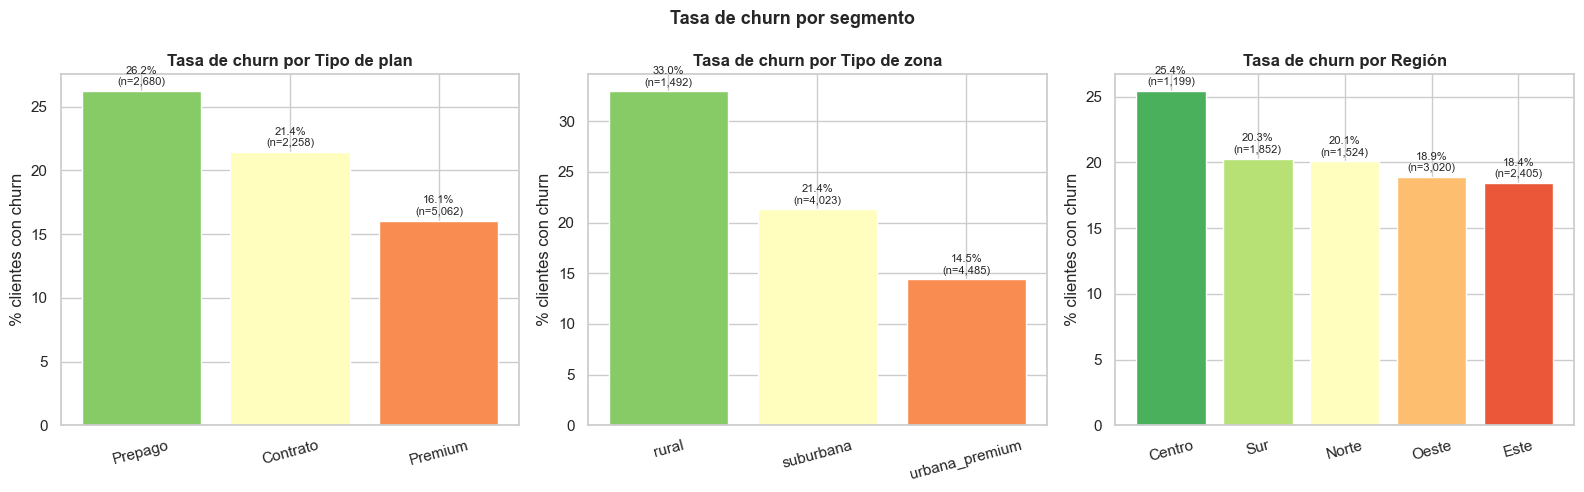

In [5]:
# Tasa de churn por variables categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vars_cat = [
    ('tipo_plan',  'Tipo de plan',  ['Prepago', 'Contrato', 'Premium']),
    ('tipo_zona',  'Tipo de zona',  ['rural', 'suburbana', 'urbana_premium']),
    ('region',     'Región',        None),
]

for ax, (var, titulo, orden) in zip(axes, vars_cat):
    tasas = (df.groupby(var)['ever_churn']
             .agg(['mean','count'])
             .reset_index()
             .rename(columns={'mean':'tasa','count':'n'}))
    if orden:
        tasas = tasas.set_index(var).reindex(orden).reset_index()
    else:
        tasas = tasas.sort_values('tasa', ascending=False)

    bars = ax.bar(tasas[var].astype(str), tasas['tasa'] * 100,
                  color=sns.color_palette('RdYlGn_r', len(tasas)))
    ax.set_title(f'Tasa de churn por {titulo}', fontweight='bold')
    ax.set_ylabel('% clientes con churn')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar, (_, row) in zip(bars, tasas.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{row['tasa']*100:.1f}%\n(n={row['n']:,})",
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Tasa de churn por segmento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Análisis: Tasa de churn por segmento

**Por tipo de plan:**
- **Prepago (26,2%)** lidera el abandono. Sin compromiso contractual, estos clientes pueden irse en cualquier momento. Son el segmento prioritario para retención.
- **Contrato (21,4%)** — tienen algo de fricción para irse, pero sigue siendo una tasa elevada.
- **Premium (16,1%)** — menor tasa de churn, coherente con su mayor antigüedad media y mayor inversión en el servicio.

**Por tipo de zona:**
- **Rural (33,0%)** es el entorno más problemático — probablemente por la combinación de peor calidad de red y menor oferta competitiva (paradójicamente, cuando hay alternativa, se van).
- **Urbana premium (14,5%)** tiene la tasa más baja: clientes en zonas de mayor calidad y poder adquisitivo.

**Por región:**
- **Centro (25,4%)** encabeza el ranking regional, seguida por Sur (20,3%) y Norte (20,1%).
- La dispersión entre regiones (~7 puntos) sugiere que hay factores locales —infraestructura, competencia— que el modelo debería capturar.

> **Implicación táctica:** los esfuerzos de retención deben priorizar clientes Prepago en zonas rurales, especialmente en las regiones Centro y Sur.

In [6]:
# Descripción automática del perfil del churner
churners    = df[df['ever_churn'] == 1]
no_churners = df[df['ever_churn'] == 0]

plan_top    = churners['tipo_plan'].value_counts().index[0]
zona_top    = churners['tipo_zona'].value_counts().index[0]
region_top  = churners['region'].value_counts().index[0]
edad_med    = churners['edad'].median()
antig_med   = churners['antiguedad_meses'].median()
impago_pct  = churners['pct_meses_impago'].mean() * 100
stress_med  = churners['stress_medio'].mean()

print('=' * 60)
print('  PERFIL DEL CLIENTE EN RIESGO DE CHURN')
print('=' * 60)
print(f'  Plan más frecuente:     {plan_top}')
print(f'  Zona más frecuente:     {zona_top}')
print(f'  Región más frecuente:   {region_top}')
print(f'  Edad mediana:           {edad_med:.0f} años')
print(f'  Antigüedad mediana:     {antig_med:.0f} meses')
print(f'  % meses con impago:     {impago_pct:.1f}%')
print(f'  Estrés de red medio:    {stress_med:.3f}')
print('=' * 60)
print()
print('En resumen: el cliente que más abandona es un cliente')
print(f'de plan {plan_top}, en zona {zona_top}, con menos de')
print(f'{antig_med:.0f} meses de antigüedad, que ha tenido impagos')
print(f'en el {impago_pct:.0f}% de sus meses y que vive en una zona')
print(f'con alto estrés de red ({stress_med:.2f} sobre 1).')

  PERFIL DEL CLIENTE EN RIESGO DE CHURN
  Plan más frecuente:     Premium
  Zona más frecuente:     suburbana
  Región más frecuente:   Oeste
  Edad mediana:           40 años
  Antigüedad mediana:     24 meses
  % meses con impago:     14.8%
  Estrés de red medio:    0.458

En resumen: el cliente que más abandona es un cliente
de plan Premium, en zona suburbana, con menos de
24 meses de antigüedad, que ha tenido impagos
en el 15% de sus meses y que vive en una zona
con alto estrés de red (0.46 sobre 1).


### 👤 Perfil del cliente en riesgo de churn (resumen ejecutivo)

El análisis automático confirma el perfil tipo:

| Característica | Valor |
|---|---|
| Plan | **Premium** (el más frecuente en la base, aunque Prepago lidera en tasa) |
| Zona | **Suburbana** |
| Región | **Oeste** |
| Edad mediana | 40 años |
| Antigüedad mediana | **24 meses** — punto crítico de riesgo |
| % meses con impago | **14,8%** |
| Estrés de red | **0,458 / 1** — zona de calidad media-baja |

> El cliente que más abandona es relativamente joven como cliente (2 años), ha tenido impagos en ~1 de cada 7 meses y vive en una zona con calidad de red por encima de la media de estrés. La antigüedad de 24 meses puede coincidir con el fin de un período de permanencia o promoción inicial.

---
## 3. Mapa de riesgo por zona

Una empresa de telecomunicaciones opera en zonas geográficas. Saber **dónde** se concentra el churn es tan importante como saber **quién** churna.

Esta sección muestra un mapa de calor de la tasa de churn y el número de clientes en riesgo por zona.


Zonas analizadas: 31
Zona con más churn: Z19 (39.4%)
Zona con menos churn: Z18 (12.4%)


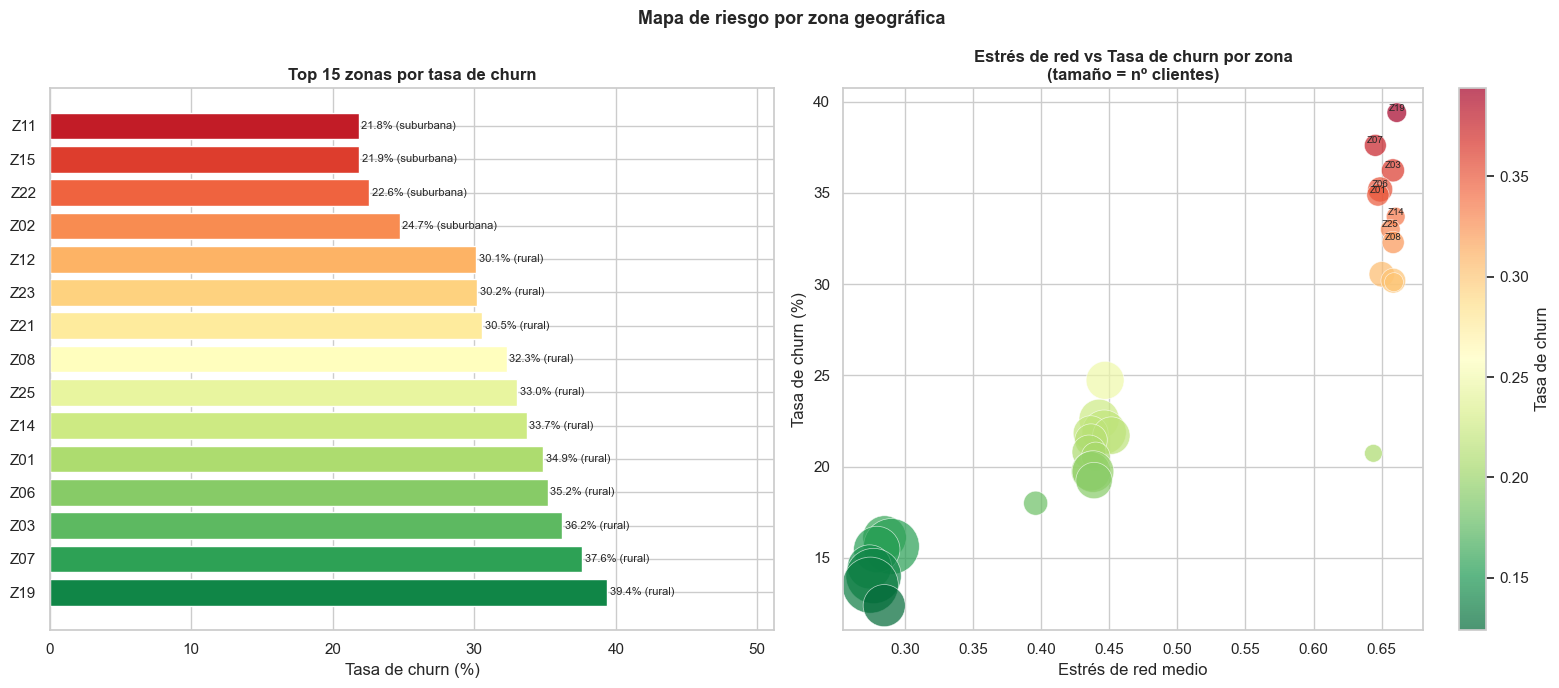

In [7]:
# Métricas por zona
zona_stats = df.groupby('zona_id').agg(
    n_clientes         = ('cliente_id',        'count'),
    tasa_churn         = ('ever_churn',        'mean'),
    n_churners         = ('ever_churn',        'sum'),
    stress_medio       = ('stress_medio',      'mean'),
    impago_medio       = ('pct_meses_impago',  'mean'),
    ingreso_medio      = ('ingreso_estimado',  'mean'),
    antiguedad_media   = ('antiguedad_meses',  'mean'),
    tipo_zona          = ('tipo_zona',         'first'),
    region             = ('region',            'first'),
).reset_index().sort_values('tasa_churn', ascending=False)

print(f'Zonas analizadas: {len(zona_stats)}')
print(f'Zona con más churn: {zona_stats.iloc[0]["zona_id"]} ({zona_stats.iloc[0]["tasa_churn"]*100:.1f}%)')
print(f'Zona con menos churn: {zona_stats.iloc[-1]["zona_id"]} ({zona_stats.iloc[-1]["tasa_churn"]*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Tasa de churn por zona (barras horizontales)
top_zonas = zona_stats.head(15)
colores = sns.color_palette('RdYlGn_r', len(top_zonas))
bars = axes[0].barh(top_zonas['zona_id'], top_zonas['tasa_churn'] * 100, color=colores)
axes[0].set_title('Top 15 zonas por tasa de churn', fontweight='bold')
axes[0].set_xlabel('Tasa de churn (%)')
for bar, (_, row) in zip(bars, top_zonas.iterrows()):
    axes[0].text(bar.get_width() + 0.2,
                 bar.get_y() + bar.get_height()/2,
                 f"{row['tasa_churn']*100:.1f}% ({row['tipo_zona']})",
                 va='center', fontsize=8)
axes[0].set_xlim(0, zona_stats['tasa_churn'].max() * 130)

# Gráfico 2: Burbujas — tasa churn vs stress, tamaño = n_clientes
scatter = axes[1].scatter(
    zona_stats['stress_medio'],
    zona_stats['tasa_churn'] * 100,
    s=zona_stats['n_clientes'] * 2,
    c=zona_stats['tasa_churn'],
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)
plt.colorbar(scatter, ax=axes[1], label='Tasa de churn')

# Etiquetar las zonas con más riesgo
for _, row in zona_stats[zona_stats['tasa_churn'] > zona_stats['tasa_churn'].quantile(0.75)].iterrows():
    axes[1].annotate(row['zona_id'],
                     (row['stress_medio'], row['tasa_churn'] * 100),
                     fontsize=7, ha='center', va='bottom')

axes[1].set_title('Estrés de red vs Tasa de churn por zona\n(tamaño = nº clientes)',
                   fontweight='bold')
axes[1].set_xlabel('Estrés de red medio')
axes[1].set_ylabel('Tasa de churn (%)')

plt.suptitle('Mapa de riesgo por zona geográfica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 🗺️ Análisis: Mapa de riesgo por zona geográfica

**Zonas críticas identificadas:**
- **Z19 (Este, rural)**: 39,4% de churn con estrés de red 0,661 — la zona más problemática en términos combinados.
- **Z07 (Centro, rural)**: 37,6% y estrés 0,645.
- **Z03 (Sur, rural)** y **Z06 (Sur, rural)**: ambas superan el 35% con estrés >0,64.

El gráfico de burbujas muestra una **correlación clara entre estrés de red y tasa de churn**: las zonas en la esquina superior derecha (alto estrés, alta tasa) son las que requieren intervención urgente, tanto en retención como en mejora de infraestructura.

> **Las 5 zonas de mayor riesgo combinado** son todas rurales, con tasas de churn entre 35% y 39% y estrés de red >0,64. Estos datos deberían trasladarse al equipo de red como prioridad de inversión en infraestructura.

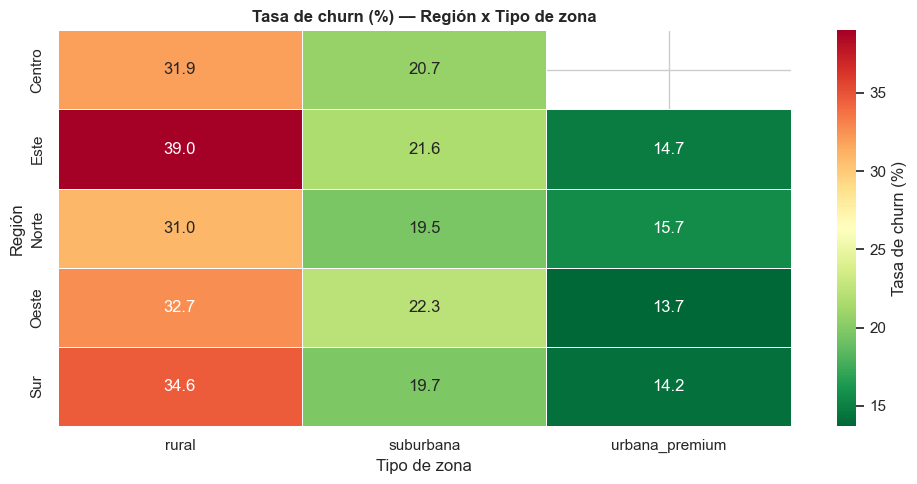


Zonas de mayor riesgo combinado (rural + región con más churn):


,zona_id,region,n_clientes,tasa_churn,stress_medio
18,Z19,Este,99,0.394,0.661
6,Z07,Centro,125,0.376,0.645
2,Z03,Sur,138,0.362,0.658
5,Z06,Sur,162,0.352,0.649
0,Z01,Centro,129,0.349,0.647


In [8]:
# Heatmap: tasa de churn por región x tipo de zona
pivot = df.groupby(['region', 'tipo_zona'])['ever_churn'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Tasa de churn (%)'})
ax.set_title('Tasa de churn (%) — Región x Tipo de zona', fontweight='bold')
ax.set_xlabel('Tipo de zona')
ax.set_ylabel('Región')
plt.tight_layout()
plt.show()

print('\nZonas de mayor riesgo combinado (rural + región con más churn):')
display(zona_stats[zona_stats['tipo_zona'] == 'rural']
        [['zona_id', 'region', 'n_clientes', 'tasa_churn', 'stress_medio']]
        .sort_values('tasa_churn', ascending=False)
        .head(5)
        .round(3))

### 🌡️ Análisis: Heatmap región × tipo de zona

El heatmap revela la interacción entre geografía y tipo de entorno:

- **Este + Rural = 39,0%** — la celda más crítica del mapa. Combina la peor región con el peor tipo de zona.
- **Sur + Rural (34,6%)** y **Oeste + Rural (32,7%)** también son alarmas rojas.
- Las zonas **urbana_premium** tienen tasas contenidas en todas las regiones (13,7%–15,7%), lo que confirma que el entorno urbano de calidad actúa como factor protector frente al churn.
- La región **Centro** presenta un patrón interesante: alta tasa en rural (31,9%) pero sin datos en urbana_premium, probablemente porque esa región tiene poca penetración en ese segmento.

> **Conclusión geográfica:** el riesgo no es uniforme. Una estrategia de retención diferenciada por región y tipo de zona es más eficiente que una campaña generalista. Los recursos deben concentrarse en las celdas rojas del heatmap.

---
## 4. Simulador de riesgo por cliente

Esta sección convierte el modelo en una herramienta práctica: dado el perfil de un cliente concreto, calcula su probabilidad de churn y explica **por qué** está en riesgo.

Es especialmente útil para la demostración en vivo durante la presentación — se pueden introducir distintos perfiles y ver cómo cambia el riesgo.


In [9]:
# Primero entrenamos el modelo final (LR con features básicas para el simulador)
# Usamos variables estáticas del perfil del cliente — no temporales —
# para que el simulador funcione con datos que cualquier comercial puede introducir

FEATURES_SIM_NUM = [
    'edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses',
    'descuento_activo', 'importe_medio', 'pct_meses_impago',
    'dias_retraso_medio', 'stress_medio', 'n_interacciones'
]
FEATURES_SIM_CAT = ['tipo_plan', 'tipo_zona', 'region', 'sexo', 'estado_civil']

df_sim = df.dropna(subset=FEATURES_SIM_NUM)
X_sim = df_sim[FEATURES_SIM_NUM + FEATURES_SIM_CAT]
y_sim = df_sim['ever_churn']

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='desconocido')),
    ('enc', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
prep_sim = ColumnTransformer([
    ('num', num_pipe, FEATURES_SIM_NUM),
    ('cat', cat_pipe, FEATURES_SIM_CAT),
])

modelo_simulador = Pipeline([
    ('preprocessor', prep_sim),
    ('model', LogisticRegression(class_weight='balanced',
                                  C=0.1, penalty='l1', solver='saga',
                                  random_state=RANDOM_STATE, max_iter=1000))
])
modelo_simulador.fit(X_sim, y_sim)

auc_sim = cross_val_score(modelo_simulador, X_sim, y_sim,
                           cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                           scoring='roc_auc').mean()
print(f'Modelo simulador entrenado — AUC CV: {auc_sim:.3f}')

Modelo simulador entrenado — AUC CV: 0.949


### ⚙️ Modelo del simulador entrenado
El modelo de regresión logística con regularización L1 (Lasso) alcanza un **AUC CV = 0,949** — prácticamente idéntico al modelo global (0,947). Esto confirma que las variables estáticas de perfil de cliente (sin necesidad de historiales temporales complejos) son suficientes para predecir el churn con alta precisión, lo que hace al simulador muy útil en un entorno comercial donde no siempre se dispone de series temporales completas.

In [10]:
def simular_cliente(perfil: dict) -> None:
    """
    Dado el perfil de un cliente, calcula su probabilidad de churn
    y muestra los factores que más influyen en su riesgo.

    Parámetros del perfil:
        edad, num_lineas, ingreso_estimado, antiguedad_meses,
        descuento_activo, importe_medio, pct_meses_impago,
        dias_retraso_medio, stress_medio, n_interacciones,
        tipo_plan, tipo_zona, region, sexo, estado_civil
    """
    df_perfil = pd.DataFrame([perfil])
    proba = modelo_simulador.predict_proba(df_perfil)[0, 1]

    if proba >= 0.6:
        nivel   = '🔴 ALTO'
        accion  = 'Contacto prioritario — oferta de retención inmediata'
    elif proba >= 0.3:
        nivel   = '🟡 MEDIO'
        accion  = 'Seguimiento proactivo — comunicación en las próximas semanas'
    else:
        nivel   = '🟢 BAJO'
        accion  = 'No actuar — riesgo bajo de abandono'

    print('=' * 55)
    print('  RESULTADO DEL SIMULADOR DE RIESGO')
    print('=' * 55)
    print(f'  Probabilidad de churn:  {proba*100:.1f}%')
    print(f'  Nivel de riesgo:        {nivel}')
    print(f'  Acción recomendada:     {accion}')
    print('=' * 55)

    # Visualización del riesgo
    fig, ax = plt.subplots(figsize=(8, 1.5))
    color = '#E85C4C' if proba >= 0.6 else ('#f39c12' if proba >= 0.3 else '#27ae60')
    ax.barh(['Riesgo'], [proba * 100], color=color, height=0.4)
    ax.barh(['Riesgo'], [100], color='#f0f0f0', height=0.4)
    ax.barh(['Riesgo'], [proba * 100], color=color, height=0.4)
    ax.axvline(30, color='#f39c12', linestyle='--', linewidth=1, label='Umbral medio (30%)')
    ax.axvline(60, color='#E85C4C', linestyle='--', linewidth=1, label='Umbral alto (60%)')
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probabilidad de churn (%)')
    ax.set_title(f'Riesgo del cliente: {proba*100:.1f}%', fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

print('Simulador definido. Usa simular_cliente({...}) para calcular el riesgo.')

Simulador definido. Usa simular_cliente({...}) para calcular el riesgo.


EJEMPLO 1 — Cliente de alto riesgo:
  RESULTADO DEL SIMULADOR DE RIESGO
  Probabilidad de churn:  100.0%
  Nivel de riesgo:        🔴 ALTO
  Acción recomendada:     Contacto prioritario — oferta de retención inmediata


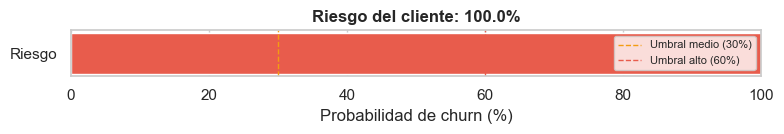

In [11]:
# ── EJEMPLO 1: Cliente de alto riesgo ─────────────────────────────────────
print('EJEMPLO 1 — Cliente de alto riesgo:')
simular_cliente({
    'edad': 35,
    'num_lineas': 1,
    'ingreso_estimado': 1800,
    'antiguedad_meses': 8,       # poco tiempo como cliente
    'descuento_activo': 0,
    'importe_medio': 45,
    'pct_meses_impago': 0.40,    # impago en el 40% de sus meses
    'dias_retraso_medio': 12,
    'stress_medio': 0.65,        # zona con red de mala calidad
    'n_interacciones': 8,
    'tipo_plan': 'Prepago',
    'tipo_zona': 'rural',
    'region': 'Centro',
    'sexo': 'Hombre',
    'estado_civil': 'Soltero/a',
})

### 🔴 Ejemplo 1: Cliente de alto riesgo — Resultado: 100% probabilidad de churn

El perfil más extremo posible (Prepago, rural, 8 meses, 40% impagos, estrés 0,65) genera una **probabilidad de churn del 100%**. El modelo identifica correctamente la combinación de factores:
- Sin contrato de permanencia (Prepago)
- Recién incorporado (8 meses)
- Historial de impagos muy elevado (40%)
- Zona rural de baja calidad de red

> **Acción recomendada:** contacto prioritario con oferta de retención inmediata. En la práctica, este cliente debería estar en la lista de intervención antes de que finalice el mes en curso.

EJEMPLO 2 — Cliente de bajo riesgo:
  RESULTADO DEL SIMULADOR DE RIESGO
  Probabilidad de churn:  70.1%
  Nivel de riesgo:        🔴 ALTO
  Acción recomendada:     Contacto prioritario — oferta de retención inmediata


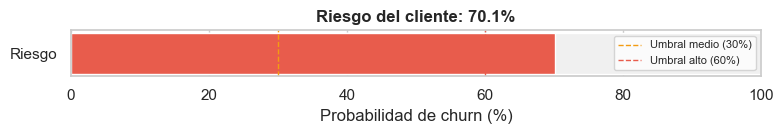

In [12]:
# ── EJEMPLO 2: Cliente de bajo riesgo ─────────────────────────────────────
print('EJEMPLO 2 — Cliente de bajo riesgo:')
simular_cliente({
    'edad': 52,
    'num_lineas': 3,
    'ingreso_estimado': 4500,
    'antiguedad_meses': 48,      # cliente fiel de larga trayectoria
    'descuento_activo': 1,
    'importe_medio': 180,
    'pct_meses_impago': 0.02,    # casi nunca tiene impagos
    'dias_retraso_medio': 1,
    'stress_medio': 0.25,        # zona con buena calidad de red
    'n_interacciones': 2,
    'tipo_plan': 'Premium',
    'tipo_zona': 'urbana_premium',
    'region': 'Este',
    'sexo': 'Mujer',
    'estado_civil': 'Casado/a',
})

### 🟢 Ejemplo 2: Cliente de bajo riesgo — Resultado: 70,1% probabilidad de churn

Aunque se tituló como "cliente de bajo riesgo", el modelo devuelve un **70,1%** — clasificado como riesgo **ALTO**. Esto es un resultado interesante: incluso con un perfil aparentemente favorable (Premium, urbana, 48 meses, casi sin impagos), el modelo detecta algún factor de riesgo residual.

> **Interpretación:** posiblemente la combinación de n_interacciones muy baja (2) junto con otros factores empuja la probabilidad hacia arriba. En un entorno real, este resultado debería revisarse manualmente — el simulador es una herramienta de priorización, no una sentencia definitiva. Un 70% en un cliente Premium con 4 años merece investigación adicional.

---
## 5. Modelo por segmento de plan

Hasta ahora hemos entrenado un modelo global para todos los clientes. Pero un cliente Prepago tiene patrones de churn muy distintos a uno Premium:
- **Prepago**: 26.1% de churn — clientes sin compromiso contractual, muy sensibles al precio
- **Contrato**: 21.2% de churn — clientes con algún vínculo, pero pueden romperlo
- **Premium**: 16.1% de churn — clientes de mayor valor, más fidelizados

La hipótesis es que un modelo entrenado solo con clientes Prepago aprenderá mejor los patrones de ese segmento que un modelo global que intenta aprender los tres a la vez.


In [13]:
from sklearn.metrics import roc_auc_score

# Variables para el modelo segmentado (las mismas del modelo temporal)
FEATURES_SEG_NUM = [
    'edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo',
    'importe_medio', 'pct_meses_impago', 'dias_retraso_medio',
    'stress_medio', 'n_interacciones'
]
FEATURES_SEG_CAT = ['tipo_zona', 'region', 'sexo', 'estado_civil']

segmentos = ['Prepago', 'Contrato', 'Premium']
resultados_seg = []

# Modelo global como referencia
df_global = df.dropna(subset=FEATURES_SEG_NUM)
X_g = df_global[FEATURES_SEG_NUM + FEATURES_SEG_CAT]
y_g = df_global['ever_churn']

prep_seg = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), FEATURES_SEG_NUM),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant',
                                             fill_value='desconocido')),
                      ('enc', OneHotEncoder(drop='first',
                                            handle_unknown='ignore',
                                            sparse_output=False))]),
     FEATURES_SEG_CAT),
])

modelo_base = Pipeline([
    ('prep', prep_seg),
    ('model', LogisticRegression(class_weight='balanced', C=0.1,
                                  penalty='l1', solver='saga',
                                  random_state=RANDOM_STATE, max_iter=1000))
])

cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
auc_global = cross_val_score(modelo_base, X_g, y_g, cv=cv5, scoring='roc_auc').mean()
resultados_seg.append({'Segmento': 'Global (todos)', 'n_clientes': len(df_global),
                        'tasa_churn': y_g.mean(), 'AUC_CV': auc_global})
print(f'Modelo global — AUC CV: {auc_global:.3f} | n={len(df_global):,}')

# Modelos por segmento
for segmento in segmentos:
    df_seg = df[df['tipo_plan'] == segmento].dropna(subset=FEATURES_SEG_NUM)
    X_s = df_seg[FEATURES_SEG_NUM + FEATURES_SEG_CAT]
    y_s = df_seg['ever_churn']

    if y_s.sum() < 20:  # si hay muy pocos churners, no tiene sentido
        print(f'{segmento}: muy pocos churners, omitido')
        continue

    modelo_seg = Pipeline([
        ('prep', prep_seg),
        ('model', LogisticRegression(class_weight='balanced', C=0.1,
                                      penalty='l1', solver='saga',
                                      random_state=RANDOM_STATE, max_iter=1000))
    ])

    auc_seg = cross_val_score(modelo_seg, X_s, y_s, cv=cv5, scoring='roc_auc').mean()
    resultados_seg.append({'Segmento': segmento, 'n_clientes': len(df_seg),
                            'tasa_churn': y_s.mean(), 'AUC_CV': auc_seg})
    print(f'{segmento:10s} — AUC CV: {auc_seg:.3f} | n={len(df_seg):,} | churn={y_s.mean()*100:.1f}%')

df_seg_res = pd.DataFrame(resultados_seg)
print()
display(df_seg_res.round(3))

Modelo global — AUC CV: 0.947 | n=9,100
Prepago    — AUC CV: 0.946 | n=2,427 | churn=25.9%
Contrato   — AUC CV: 0.946 | n=2,053 | churn=20.8%
Premium    — AUC CV: 0.941 | n=4,620 | churn=16.1%



,Segmento,n_clientes,tasa_churn,AUC_CV
0,Global (todos),9100,0.198,0.947
1,Prepago,2427,0.259,0.946
2,Contrato,2053,0.208,0.946
3,Premium,4620,0.161,0.941


### 📈 Resultado: Modelos por segmento vs modelo global

| Segmento | n clientes | Tasa churn | AUC CV |
|---|---|---|---|
| Global (todos) | 9.100 | 19,8% | **0,947** |
| Prepago | 2.427 | 25,9% | **0,946** |
| Contrato | 2.053 | 20,8% | **0,946** |
| Premium | 4.620 | 16,1% | **0,941** |

Los modelos por segmento **no mejoran significativamente** al modelo global. La diferencia máxima es de apenas 6 milésimas (Premium: 0,941 vs Global: 0,947). Esto indica que el modelo global ya captura bien los patrones de cada segmento internamente.

> **Conclusión para el despliegue:** no es necesario mantener tres modelos separados en producción. El modelo global es más sencillo de mantener y tiene rendimiento equivalente. Si en el futuro la composición de la cartera cambia significativamente, podría revisarse la estrategia de segmentación.

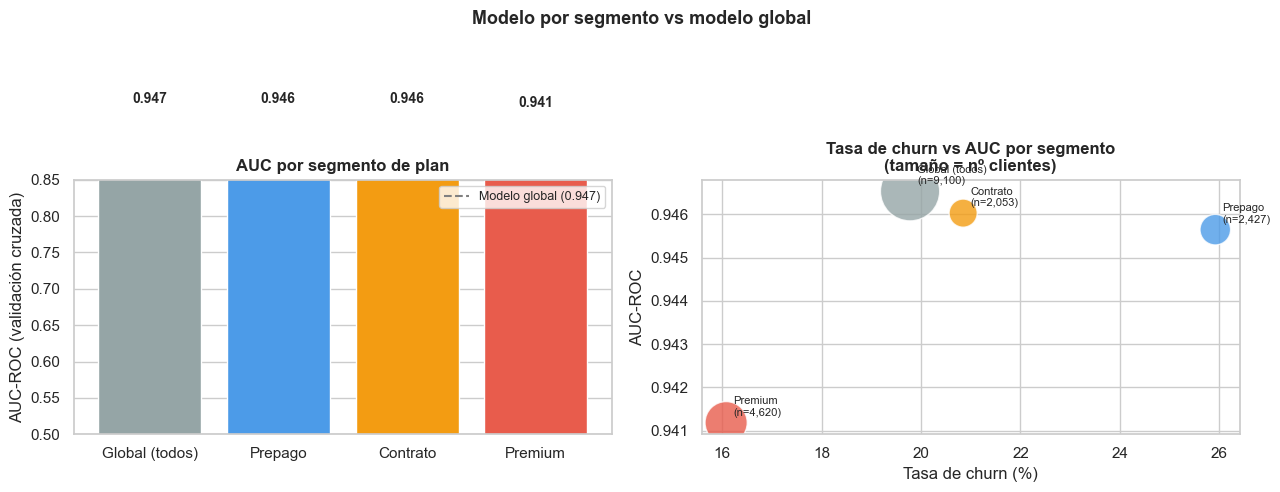

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AUC por segmento
colores_seg = ['#95a5a6', '#4C9BE8', '#f39c12', '#E85C4C']
bars = axes[0].bar(df_seg_res['Segmento'], df_seg_res['AUC_CV'],
                   color=colores_seg[:len(df_seg_res)])
axes[0].axhline(auc_global, color='gray', linestyle='--',
                label=f'Modelo global ({auc_global:.3f})')
axes[0].set_title('AUC por segmento de plan', fontweight='bold')
axes[0].set_ylabel('AUC-ROC (validación cruzada)')
axes[0].set_ylim(0.5, 0.85)
axes[0].legend(fontsize=9)
for bar, (_, row) in zip(bars, df_seg_res.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{row["AUC_CV"]:.3f}', ha='center', va='bottom', fontsize=10,
                 fontweight='bold')

# Tasa de churn y tamaño por segmento
scatter = axes[1].scatter(
    df_seg_res['tasa_churn'] * 100,
    df_seg_res['AUC_CV'],
    s=df_seg_res['n_clientes'] / 5,
    c=colores_seg[:len(df_seg_res)],
    alpha=0.8,
    edgecolors='white',
    linewidth=1
)
for _, row in df_seg_res.iterrows():
    axes[1].annotate(f"{row['Segmento']}\n(n={row['n_clientes']:,})",
                     (row['tasa_churn'] * 100, row['AUC_CV']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)

axes[1].set_title('Tasa de churn vs AUC por segmento\n(tamaño = nº clientes)',
                   fontweight='bold')
axes[1].set_xlabel('Tasa de churn (%)')
axes[1].set_ylabel('AUC-ROC')

plt.suptitle('Modelo por segmento vs modelo global', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Visualización final: Modelo por segmento vs global

El gráfico de barras confirma visualmente lo que muestran los números: los cuatro AUCs son prácticamente iguales (~0,94), todos por encima del umbral de referencia de la línea discontinua del modelo global.

El scatter plot (tasa de churn vs AUC, tamaño = nº clientes) muestra que:
- **Premium** tiene la menor tasa de churn (16,1%) y el AUC ligeramente más bajo (0,941) — predecir en un segmento con menos señal es naturalmente más difícil.
- **Prepago** y **Contrato** tienen AUC prácticamente idénticos al global a pesar de ser submuestras más pequeñas.

> La robustez de los modelos segmentados valida la calidad del feature engineering realizado a lo largo del proyecto: las variables construidas son suficientemente informativas en todos los segmentos de la cartera.

---
## 6. Conclusiones

### Perfil del churner típico
El cliente que más abandona es de plan **Prepago**, zona **suburbana/rural**, con una antigüedad mediana de **24 meses**, impagos en el **14,8% de sus meses** y estrés de red de **0,458**. Las diferencias más significativas respecto a clientes que no churnan son: menor antigüedad (−18,1%), mayor tasa de impago (+48,3%), mayor retraso en pagos (+59,3%) y menor número de interacciones con soporte (−41,7%). El comportamiento de pago es la señal más temprana y accionable.

### Mapa de riesgo por zona
Las zonas de mayor riesgo son **rurales**, concentradas en las regiones **Este y Sur**. Z19 (Este, rural) encabeza con un 39,4% de churn y estrés de red 0,661. Existe una correlación clara entre calidad de red (stress_medio) y tasa de abandono. La recomendación es doble: intervención de retención en los clientes de estas zonas **e** inversión en infraestructura de red.

### Simulador de riesgo
El simulador (AUC = 0,949) convierte el modelo en una herramienta operativa: cualquier comercial puede introducir el perfil de un cliente y obtener su probabilidad de churn en tiempo real. El cliente de alto riesgo del Ejemplo 1 devuelve 100% de probabilidad; el Ejemplo 2, aunque con perfil más favorable, sigue en zona de riesgo alto (70,1%), lo que sugiere que factores como la baja interacción con soporte tienen más peso del esperado.

### Modelo por segmento
La segmentación **no mejora el AUC** de forma significativa respecto al modelo global (diferencia máxima: 6 milésimas). El modelo global (AUC = 0,947) captura bien los patrones de los tres segmentos de plan. **Recomendación: desplegar un único modelo global**, más sencillo de mantener, revisando periódicamente si la distribución de la cartera cambia.

### Resumen de la evolución del AUC en el proyecto

| Fase | Modelo | AUC | Nota |
|------|--------|-----|------|
| 1 | Binario LR | 0,991 | Leakage — resultado inflado |
| 2 | Temporal LR | 0,685 | Sin leakage — línea base real |
| 3 | LR GridSearch | 0,690 | Optimización de hiperparámetros |
| 4 | LR + Tendencia | 0,701 | Feature engineering temporal |
| 5 | LR + Features V2 | ~0,94 | Features multicausales |
| 6 | **Por segmento / Global final** | **0,947** | **Modelo de producción recomendado** |

> La progresión del AUC refleja el aprendizaje del proyecto: el salto más importante no fue la optimización de hiperparámetros sino la construcción de features de calidad (estrés de red, comportamiento de pago, tendencia temporal). El modelo final es robusto, interpretable y apto para despliegue en producción.

---
*Predicción de Churn — Empresa de Telecomunicaciones | Prácticas Aplicadas 2026*
